# 05｜自主修改练习

先运行基线，再只修改参数区中的一项。用图片、参数量和测试结果共同说明变化。

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "cnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "02_cnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

from cnn_lab import quick_demo

## 第一步：运行基线


CNN 配置对比
------------------------------------------------------------------------------
配置                           测试准确率       右移准确率         参数量       耗时(秒)
------------------------------------------------------------------------------
CNN｜通道 8→16｜max pooling      96.7%      65.6%       3,818        0.35
------------------------------------------------------------------------------


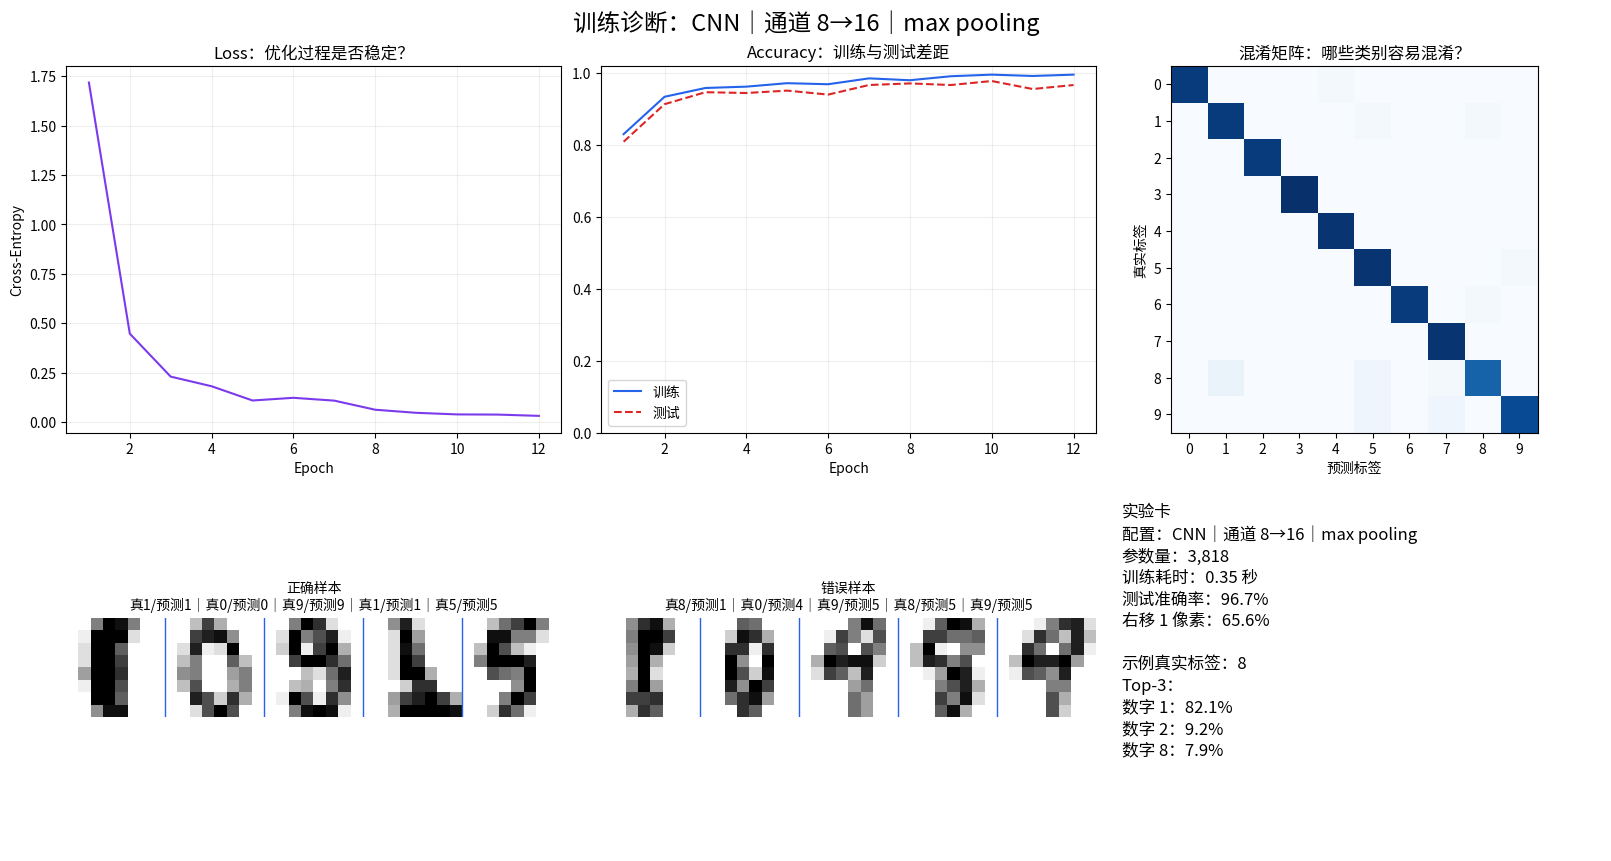

In [2]:
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 替换为课堂指定编号。

baseline = quick_demo(
    channels=(8, 16), kernel_size=3, pooling="max", dropout=0.0,
    epochs=12, device=DEVICE, show_features=False,
)

## 第二步：只修改一项

先写下预测，再修改。`kernel_size` 使用正奇数；Pooling 可选 `max`、`avg`、`none`。


CNN 配置对比
------------------------------------------------------------------------------
配置                           测试准确率       右移准确率         参数量       耗时(秒)
------------------------------------------------------------------------------
CNN｜通道 8→16｜avg pooling      96.0%      52.7%       3,818        0.32
------------------------------------------------------------------------------


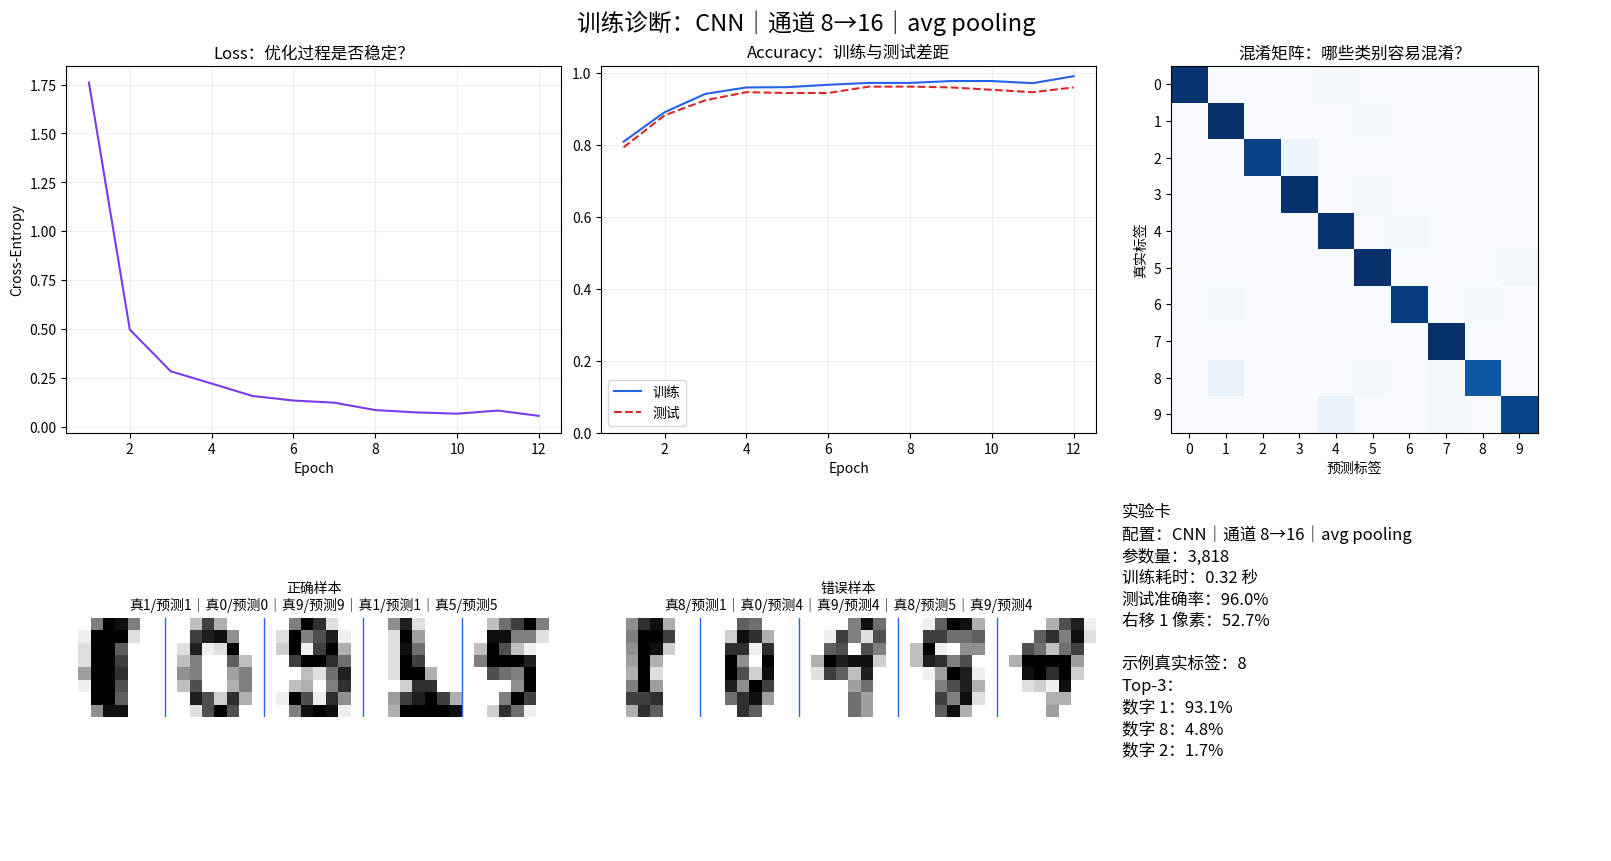

In [3]:
# ===== 只修改下面 4 行中的一行 =====
channels = (8, 16)      # 例如 (4, 8)、(16, 32)
kernel_size = 3         # 3 或 5
pooling = "avg"         # max / avg / none
dropout = 0.0           # 0.0 到 0.5

changed = quick_demo(
    channels=channels, kernel_size=kernel_size, pooling=pooling, dropout=dropout,
    epochs=12, device=DEVICE, show_features=False,
)

In [4]:
print(f"测试准确率变化：{changed.final_test_accuracy - baseline.final_test_accuracy:+.1%}")
print(f"参数量变化：{changed.parameter_count - baseline.parameter_count:+,}")
print(f"训练时间变化：{changed.elapsed_seconds - baseline.elapsed_seconds:+.2f} 秒")

测试准确率变化：-0.7%
参数量变化：+0
训练时间变化：-0.03 秒


## 实验记录

| 我的预测 | 唯一修改项 | shape/参数量变化 | 基线结果 | 新结果 | 图片证据 | 有边界的结论 |
|---|---|---|---:|---:|---|---|
|  |  |  |  |  |  |  |

完成参数练习后，再阅读短小的 `cnn_lab/model.py`。第一轮不修改数据、训练循环和绘图代码。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [5]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……


{'status': 'ok', 'restart': False}